---
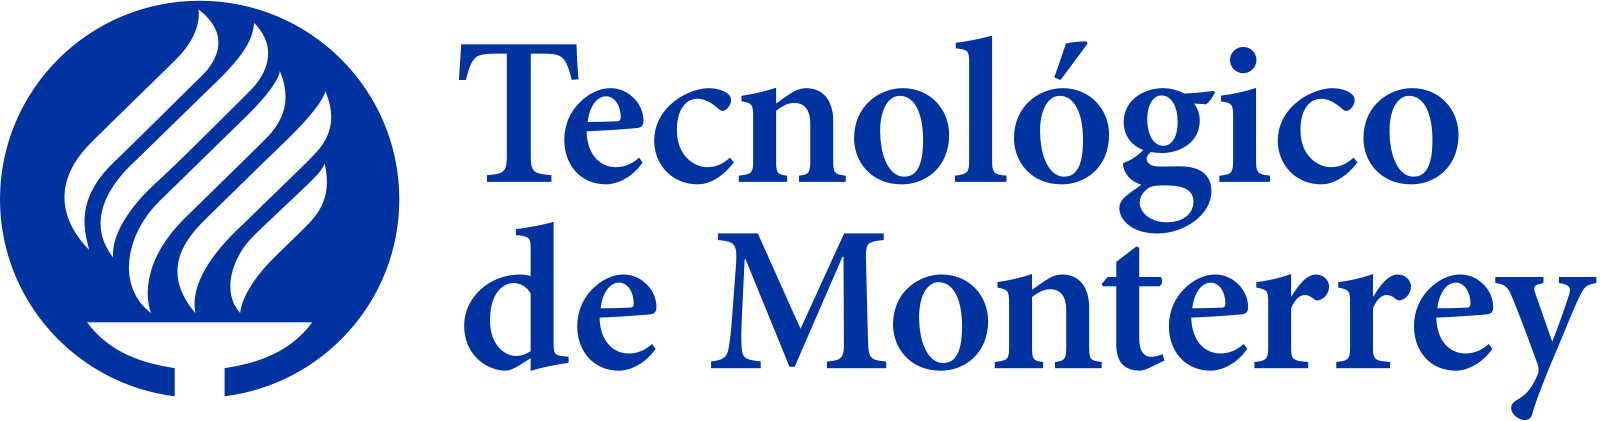

---

**Nombre:** Amilka Daniela Lopez Aguilar

**Matrícula:** A01029277

**Materia:** Inteligencia artificial avanzada para la ciencia de datos

**Docente:** Esteban Castillo Juarez

**Grupo:** 601  

**Fecha:** 3 de septiembre de 2026

---

###**Introducción**

Realizar un análisis de sentimientos en la plataforma X, utilizando el algoritmo de Naive Bayes para clasificar comentarios como positivos, negativos o neutrales.

###**Objetivos**

* Reforzar la teoría de Naive Bayes aplicando el algoritmo de clasificación
sobre el mismo conjunto de datos utilizado en las sesiones, pero con más
clases (etiquetas de clasificación).

* Practica la teoría detrás de Naive Bayes en el contexto del lenguaje de
programación Python con Scikit-learn.

* Reforzar tópicos como el uso de métricas o la validación cruzada.

###**Acerca del conjunto de datos**

Se trata de una muestra de mensajes provenientes de la plataforma X, etiquetados en tres categorías principales: positivo, negativo y neutral.

El conjunto de datos fue preprocesado para evitar problemas de
codificación. El preprocesamiento incluyó la eliminación de símbolos
de puntuación, URLs, espacios extra y elementos que no forman parte
de la codificación ASCII.

El conjunto de entrenamiento cuenta con 4187 muestras, de las cuales **2249 son positivas, 859 son negativas, 1079 son neutrales**

El conjunto de prueba cuenta con 867 muestras, de las cuales **358 son positivas, 179 son negativas, 330 son neutrales**

###**Metodologia y Enfoque**

Para esta actividad se utilizará el conjunto de datos previamente descrito, con el objetivo de entrenar y evaluar un clasificador Naive Bayes mediante dos implementaciones: una implementación manual del algoritmo y una implementación utilizando la biblioteca Scikit-learn.

La experimentacion se hara en las siguientes etapas:

###1. Carga y preparacion de datos:

Se cargarán los conjuntos de entrenamiento y prueba correspondientes.

Debido a la distribucion de los datos en la muestra, se propone poner en desorden las muestras positivas (barajar por si ciertas muestras se concentran en algun espacio del conjunto de datos), y tomar al azar muestras negativas y neutrales. Se seguira trabajando con el resto del conjunto de datos, es decir, no se eliminaran los datos no escogidos con el fin de evaluar el desempeño del clasificador con todos los datos incorporados.

###2. Implementacion Manual de Naive Bayes

Se implementará manualmente el algoritmo de Naive Bayes utilizando el conjunto de entrenamiento.

La implementación considerará el proceso de actualización de los parámetros del modelo mediante el algoritmo utilizado en clase.


###3. Implementacion en Scikit Learn de Naive Bayes

Se implementara MultinomialNB de Scikit Learn, una variante del algoritmo Naive Bayes que resulta especialmente apropiada para situaciones en las que se trabajan con características discretas. El modelo parte del supuesto de que las probabilidades siguen una distribución multinomial, es decir, considera que las características representan la frecuencia con la que determinados eventos se producen dentro de un conjunto de experimentos.

###4. Formato de vectores: Bag of Words

El algoritmo de Naive Bayes maneja clases a traves de vectores, por lo que se propone utilizar un vector tipo bolsa de palabras o Bag of Words, donde la clasificacion no es binaria, sino en base a frecuencia de aparicion, lo cual resulta mas adecuado para un analisis de sentimientos.

###5. Uso de K-Folds o validacion cruzada

Uso de distintas instancias de los datos para la clasificacion, evitando aumento en el recuerdo del modelo por falta de subconjuntos de datos distintos, haciendolo viable para recibir otros conjuntos de datos mas adelante.

###6. Variacion de la K en K-Folds, cabtidad de caracteristicas (vocabulario) a utilizar

Entrenamiento del modelo utilizando 20, 40, 60, 80, 100 y 120 características a escoger (vocabulario). Evalúar el desempeño aplicando validación cruzada con
K = 3, 4, 5 y 6.

###7. Valoracion de precision, recuerdo, F1

Empleo de las metricas de precision, recuerdo, F1, para poder evaluar el desempeño del modelo desde distintas vertantes.



###**--Implementación Manual de Naive Bayes en Python--**

###**1. Preparación de archivos y datos**

Anteriormente se mencionó la distribución desbalanceada de los datos en ambos conjuntos, por lo que se propone barajar las muestras positivas y tomar muestras negativas/neutrales al azar por medio del barajeo de los datos.

In [173]:
from google.colab import drive

drive.mount('/content/Cancer')

print("Preprocessing steps have been skipped as requested. Proceeding to use user-provided training.txt and test.txt for shuffling.")

Drive already mounted at /content/Cancer; to attempt to forcibly remount, call drive.mount("/content/Cancer", force_remount=True).
Preprocessing steps have been skipped as requested. Proceeding to use user-provided training.txt and test.txt for shuffling.


In [174]:
import random

def load_processed_file(filepath):
  '''
  Funcion para leer los nuevos archivos procesados
  '''
  with open(filepath, 'r', encoding='utf-8') as file:
    return [line.strip() for line in file if line.strip()]

def recombine_data(texts, labels):
  '''
  Función para volver a unir los textos después de barajar
  '''
  return [
    f"{text}@@@{label}"
      for text, label in zip(texts, labels)
  ]

def prepare_data_for_shuffling(data, dataset_name=""):
  '''
  Funcion para separara datos de sus etiquetas.
  Recibe los datos a barajar y los devuelve separados por texto y etiqueta.
  También verifica la integridad del formato.
  '''
  texts = []
  labels = []
  dropped_samples_count = 0
  for i, entry in enumerate(data):
      parts = entry.split('@@@')
      if len(parts) == 2:
          texts.append(parts[0].strip())
          labels.append(parts[1].strip())
      else:
          dropped_samples_count += 1

  if dropped_samples_count > 0:
      print(f"Advertencia: Se omitieron {dropped_samples_count} muestras del conjunto '{dataset_name}' debido a un formato incorrecto.\n")
  return texts, labels

def shuffle_and_recombine(texts, labels):
  '''
  Funcion para barajar cada dato segun su etiqueta, y luego recombinar.
  Recibe los textos y etiquetas extraídos anteriormente y devuelce los datos barajados.
  '''
  combined = list(zip(texts, labels))

  positive_samples = [item for item in combined if item[1] == 'positive']
  negative_samples = [item for item in combined if item[1] == 'negative']
  neutral_samples = [item for item in combined if item[1] == 'neutral']

  random.shuffle(positive_samples)
  random.shuffle(negative_samples)
  random.shuffle(neutral_samples)

  print("Muestras seleccionadas:")
  print("Positive:", len(positive_samples))
  print("Negative:", len(negative_samples))
  print("Neutral:", len(neutral_samples))

  all_samples = (
    positive_samples +
    negative_samples +
    neutral_samples
  )

  random.shuffle(all_samples)

  shuffled_texts, shuffled_labels = zip(*all_samples)

  return list(shuffled_texts), list(shuffled_labels)

training_data = load_processed_file('/content/training.txt')
test_data = load_processed_file('/content/test.txt')

print("Datos de entrenamiento (total leídos):", len(training_data))
print("Datos de prueba (total leídos):", len(test_data))

train_texts, train_labels = prepare_data_for_shuffling(training_data, dataset_name="entrenamiento")
test_texts, test_labels = prepare_data_for_shuffling(test_data, dataset_name="prueba")

print(f"Datos de entrenamiento (después de validación de formato): {len(train_texts)}")
print(f"Datos de prueba (después de validación de formato): {len(test_texts)}")

train_texts_shuffled, train_labels_shuffled = shuffle_and_recombine(train_texts, train_labels)
test_texts_shuffled, test_labels_shuffled = shuffle_and_recombine(test_texts, test_labels)

train_shuffled = recombine_data(train_texts_shuffled, train_labels_shuffled)
test_shuffled = recombine_data(test_texts_shuffled, test_labels_shuffled)

with open('/content/training_shuffled.txt', 'w', encoding='utf-8') as file:
    file.write('\n'.join(train_shuffled))

with open('/content/test_shuffled.txt', 'w', encoding='utf-8') as file:
    file.write('\n'.join(test_shuffled))

Datos de entrenamiento (total leídos): 4187
Datos de prueba (total leídos): 867
Datos de entrenamiento (después de validación de formato): 4187
Datos de prueba (después de validación de formato): 867
Muestras seleccionadas:
Positive: 2249
Negative: 859
Neutral: 1078
Muestras seleccionadas:
Positive: 358
Negative: 179
Neutral: 330


##**2. Extracción del Vocabulario del Texto**

Para crear los vectores de entrenamiento y prueba, es necesario identificar el vocabulario asociado a las muestras. Para ello, se extraerán todos los tokens distintos de los documentos de entrenamiento y se guardarán en un archivo de texto.

In [175]:
import codecs
import operator
base_path = "/content/"
# Create a dictionary that will contain all the distinct terms/words from the training samples
vocabulary={}
# Open the training file and extract all tokens
with codecs.open(base_path+"training_shuffled.txt", "r", "UTF-8") as file:
    for line in file:
        # Separate the label and the text sample using the special character @@@
        elements=line.split("@@@")
        # Separate words by spaces and convert to lowercase
        for token in elements[0].lower().split(" "):
            # Include stop words by only checking if the token is not empty
            if token:
                # If the word is already in the vocabulary, increment the counter
                if token in vocabulary:
                    vocabulary[token]+=1
                # Otherwise, create a new entry in the dictionary with the first occurrence
                else:
                    vocabulary[token]=1
# Remove any entry corresponding to an empty character
if "" in vocabulary:
    del vocabulary[""]
# Sort the tokens by frequency (from most common to least common)
sortedVocabulary = sorted(vocabulary.items(), key=operator.itemgetter(1), reverse=True)
print("Principales tokens/palabras del vocabulario (con stopwords):")
print(sortedVocabulary[:10])
print("Guardar el vocabulario en un archivo")
# Save the vocabulary to a text file
with codecs.open(base_path+"vocabulary.txt", "w", "UTF-8") as file:
    for token in sortedVocabulary[:]:
        file.write(token[0]+","+str(token[1])+"\n")

Principales tokens/palabras del vocabulario (con stopwords):
[('the', 3507), ('to', 1978), ('in', 1302), ('on', 1217), ('a', 1151), ('and', 1150), ('i', 1140), ('of', 1025), ('for', 985), ('is', 849)]
Guardar el vocabulario en un archivo


###**3. Generar vectores de entrenamiento y prueba**

Se transforma cada documento en un vector de entrenamiento y prueba partiendo del vocabulario definido. Donde usamos la frecuencia de aparición o Bag of Words para generar estos vectores.

In [176]:
import codecs
feature_numbers = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300]
for featureNumber in feature_numbers:
    features = []
    with codecs.open(base_path + "vocabulary.txt", "r", "UTF-8") as file:
        for count, line in enumerate(file):
            if count == featureNumber:
                break
            elements = line.strip().split(",")
            features.append(elements[0])
    print(f"\nNúmero de características: {featureNumber}")
    print("Primeras 10 características:")
    print(features[:10])
    #Training and test lists which will contain the vectors
    trainingVectors=[]
    trainingLabels=[]
    testVectors=[]
    testLabels=[]
    #Open the training file to transform text to numbers
    print("Create training vectors")
    with codecs.open(base_path+"training_shuffled.txt", "r", "UTF-8") as file:
        for line in file:
          temporalVector=[]
          elements=line.strip().split("@@@")
          currentTokens=elements[0].split(" ")
          for feature in features:
            temporalVector.append(currentTokens.count(feature))
          trainingVectors.append(temporalVector)
          trainingLabels.append(elements[1].replace('\n', ''))
    print("Save training vectors into a file")
    with codecs.open(base_path+"trainingVectors.txt", "w", "UTF-8") as file:
        for vector,label in zip(trainingVectors,trainingLabels):
            file.write(",".join([str(x) for x in vector])+","+label+"\n")
    print("Create test vectors")
    #Open the test file to transfor text to numbers
    with codecs.open(base_path+"test_shuffled.txt", "r", "UTF-8") as file:
        for line in file:
          temporalVector=[]
          elements=line.split("@@@")
          currentTokens=elements[0].split(" ")
          for feature in features:
            temporalVector.append(currentTokens.count(feature))
          testVectors.append(temporalVector)
          testLabels.append(elements[1].replace('\n', ''))
    print("Save test vectors into a file")
    with codecs.open(base_path+"testVectors.txt", "w", "UTF-8") as file:
        for vector,label in zip(testVectors,testLabels):
            file.write(",".join([str(x) for x in vector])+","+label+"\n")


Número de características: 20
Primeras 10 características:
['the', 'to', 'in', 'on', 'a', 'and', 'i', 'of', 'for', 'is']
Create training vectors
Save training vectors into a file
Create test vectors
Save test vectors into a file

Número de características: 40
Primeras 10 características:
['the', 'to', 'in', 'on', 'a', 'and', 'i', 'of', 'for', 'is']
Create training vectors
Save training vectors into a file
Create test vectors
Save test vectors into a file

Número de características: 60
Primeras 10 características:
['the', 'to', 'in', 'on', 'a', 'and', 'i', 'of', 'for', 'is']
Create training vectors
Save training vectors into a file
Create test vectors
Save test vectors into a file

Número de características: 80
Primeras 10 características:
['the', 'to', 'in', 'on', 'a', 'and', 'i', 'of', 'for', 'is']
Create training vectors
Save training vectors into a file
Create test vectors
Save test vectors into a file

Número de características: 100
Primeras 10 características:
['the', 'to', 'in',

###**4. Entrenamiento**

Se define la funcion de entrenamiento en base al algortimo de Naive Bayers, donde clasificaremos partiendo de 3 clases y la probablidad de que aparezcan en los conjuntos de datos:

In [177]:
import math
def naiveBayesTraining(trainingVectors,trainingLabels):
    numberTrainingDocuments=len(trainingVectors)
    NumberFeatures=len(trainingVectors[0])
    numberPositive=len([x for x in trainingLabels if x == "positive"])
    numberNegative=len([x for x in trainingLabels if x == "negative"])
    numberNeutral=len([x for x in trainingLabels if x == "neutral"])
    pProbability=numberPositive/float(numberTrainingDocuments)
    nProbability=numberNegative/float(numberTrainingDocuments)
    neuProbability=numberNeutral/float(numberTrainingDocuments)
    pNumeratorProbability=[1]*NumberFeatures
    nNumeratorProbability=[1]*NumberFeatures
    neuNumeratorProbability=[1]*NumberFeatures
    pDenominatorProbability=NumberFeatures
    nDenominatorProbability=NumberFeatures
    neuDenominatorProbability=NumberFeatures
    for x in range(numberTrainingDocuments):
        if trainingLabels[x] == "positive":
            counter=0
            for y in trainingVectors[x]:
                pNumeratorProbability[counter]+=y
                counter+=1
            pDenominatorProbability+=sum(trainingVectors[x])
        elif trainingLabels[x]=="neutral":
            counter=0
            for y in trainingVectors[x]:
                neuNumeratorProbability[counter]+=y
                counter+=1
            neuDenominatorProbability+=sum(trainingVectors[x])
        elif trainingLabels[x]=="negative":
            counter=0
            for y in trainingVectors[x]:
                nNumeratorProbability[counter]+=y
                counter+=1
            nDenominatorProbability+=sum(trainingVectors[x])
    pWordProbability=[]
    for x in pNumeratorProbability:
        pWordProbability.append(math.log(x/float(pDenominatorProbability)))
    nWordProbability=[]
    for x in nNumeratorProbability:
        nWordProbability.append(math.log(x/float(nDenominatorProbability)))
    neuWordProbability=[]
    for x in neuNumeratorProbability:
        neuWordProbability.append(math.log(x/float(neuDenominatorProbability)))
    return (pWordProbability,nWordProbability,neuWordProbability,pProbability,nProbability,neuProbability)
result=naiveBayesTraining(trainingVectors,trainingLabels)

###**5. Clasificador**

Clasificamos de acuerdo a la clase con mayor probabilidad

In [178]:
import math
def classifyNB(testVector,pWordProbability,nWordProbability, neuWordProbability,pProbability,nProbability, neuProbability):
  # Probability of test vector given negative
  nScore = 0
  for counter in range(len(testVector)):
    nScore += testVector[counter] * nWordProbability[counter]
  nScore += math.log(nProbability)

  # Probability of test vector given positive
  pScore = 0
  for counter in range(len(testVector)):
    pScore += testVector[counter] * pWordProbability[counter]
  pScore += math.log(pProbability)

  # Probability of test vector given neutral
  neuScore = 0
  for counter in range(len(testVector)):
    neuScore += testVector[counter] * neuWordProbability[counter]
  neuScore += math.log(neuProbability)

  # Return the class with the highest probability
  if pScore > nScore and pScore > neuScore:
    return "positive"
  elif nScore > pScore and nScore > neuScore:
    return "negative"
  else:
    return "neutral"

###**6. Prueba**

In [179]:
import codecs
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score

feature_numbers = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300]
k_values = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
manual_results = []

for featureNumber in feature_numbers:
    features = []
    with codecs.open(base_path + "vocabulary.txt", "r", "UTF-8") as file:
        for count, line in enumerate(file):
            if count == featureNumber:
                break
            elements = line.strip().split(",")
            features.append(elements[0])
    samples_for_kfold = []
    labels_for_kfold = []
    with codecs.open(base_path + "training_shuffled.txt", "r", "UTF-8") as file:
        for line in file:
            elements = line.strip().split("@@@")
            currentTokens = elements[0].split(" ")
            temporalVector = []
            for feature in features:
                temporalVector.append(currentTokens.count(feature))
            samples_for_kfold.append(temporalVector)
            labels_for_kfold.append(elements[1].replace('\n', ''))
    for n_splits in k_values:
        kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        foldAccuracies = []
        foldPrecisions = []
        foldRecalls = []
        foldF1s = []
        for train_index, test_index in kfold.split(samples_for_kfold):
            trainingVectors = [samples_for_kfold[index] for index in train_index]
            trainingLabels = [labels_for_kfold[index] for index in train_index]
            testVectors = [samples_for_kfold[index] for index in test_index]
            testLabels = [labels_for_kfold[index] for index in test_index]
            model = naiveBayesTraining(trainingVectors, trainingLabels)
            predictions = []
            for vector in testVectors:
                predictedLabel = classifyNB(vector, model[0], model[1], model[2], model[3], model[4], model[5])
                predictions.append(predictedLabel)
            correctPredictions = 0
            for predictedLabel, label in zip(predictions, testLabels):
                if predictedLabel == label:
                    correctPredictions += 1
            accuracy = correctPredictions / len(testLabels) * 100
            precision = precision_score(testLabels, predictions, average='macro', zero_division=0) * 100
            recall = recall_score(testLabels, predictions, average='macro', zero_division=0) * 100
            f1 = f1_score(testLabels, predictions, average='macro', zero_division=0) * 100
            foldAccuracies.append(accuracy)
            foldPrecisions.append(precision)
            foldRecalls.append(recall)
            foldF1s.append(f1)

        averageAccuracy = sum(foldAccuracies) / len(foldAccuracies)
        averagePrecision = sum(foldPrecisions) / len(foldPrecisions)
        averageRecall = sum(foldRecalls) / len(foldRecalls)
        averageF1 = sum(foldF1s) / len(foldF1s)

        manual_results.append((featureNumber, n_splits, averageAccuracy, averagePrecision, averageRecall, averageF1))

print("\nResultados finales del Naive Bayes Manual (Cross-Validation en Training Set):")
for featureNumber, k, accuracy, precision, recall, f1 in manual_results:
    print(f"# Características: {featureNumber}, K: {k}, Exactitud: {accuracy:.2f}, Precisión: {precision:.2f}, Recuerdo: {recall:.2f}, F1: {f1:.2f}")


Resultados finales del Naive Bayes Manual (Cross-Validation en Training Set):
# Características: 20, K: 3, Exactitud: 53.11, Precisión: 38.48, Recuerdo: 33.79, F1: 25.71
# Características: 20, K: 4, Exactitud: 53.11, Precisión: 41.63, Recuerdo: 33.95, F1: 26.17
# Características: 20, K: 5, Exactitud: 53.11, Precisión: 37.80, Recuerdo: 33.78, F1: 25.66
# Características: 20, K: 6, Exactitud: 53.15, Precisión: 37.00, Recuerdo: 33.88, F1: 25.90
# Características: 20, K: 7, Exactitud: 53.25, Precisión: 38.36, Recuerdo: 33.98, F1: 25.97
# Características: 20, K: 8, Exactitud: 53.20, Precisión: 39.20, Recuerdo: 33.89, F1: 25.84
# Características: 20, K: 9, Exactitud: 53.15, Precisión: 38.11, Recuerdo: 33.89, F1: 25.88
# Características: 20, K: 10, Exactitud: 53.25, Precisión: 37.86, Recuerdo: 33.99, F1: 25.99
# Características: 20, K: 11, Exactitud: 53.15, Precisión: 39.43, Recuerdo: 33.84, F1: 25.74
# Características: 20, K: 12, Exactitud: 53.25, Precisión: 39.06, Recuerdo: 34.04, F1: 26.1

### **7. Visualización de Resultados del Naive Bayes Manual (Cross-Validation)**

Estos gráficos visualizan el rendimiento del modelo Naive Bayes manual durante la validación cruzada en el conjunto de entrenamiento, mostrando cómo la precisión, el recuerdo, la exactitud y el F1-Score varían con el número de características y el valor de K.

In [180]:
import plotly.express as px
import pandas as pd

# Convertir los resultados manuales a un DataFrame para facilitar la visualización
manual_results_df = pd.DataFrame(manual_results, columns=['Features', 'K', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

print("Visualizando resultados del Naive Bayes Manual:")

# 1. Métricas vs. Número de Características (para cada K)
for metric in metrics_to_plot:
    fig = px.line(manual_results_df, x='Features', y=metric, color='K', markers=True,
                  title=f'{metric} vs. Número de Características (Naive Bayes Manual)',
                  labels={'Features': 'Número de Características', metric: metric})
    fig.show()

# 2. Métricas vs. Valor de K (para cada Número de Características)
# Seleccionar algunos números de características representativos para evitar el desorden
representative_features = [20, 80, 160]

for metric in metrics_to_plot:
    for feature_num in representative_features:
        subset_df = manual_results_df[manual_results_df['Features'] == feature_num]
        fig = px.line(subset_df, x='K', y=metric, markers=True,
                      title=f'{metric} vs. Valor de K (Características={feature_num}, Naive Bayes Manual)',
                      labels={'K': 'Valor de K', metric: metric})
        fig.show()

Visualizando resultados del Naive Bayes Manual:


###**-- 8. Implementación de Naive Bayes en Scikit-learn --**

In [181]:
import codecs
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_validate, KFold

feature_numbers = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300]
k_values = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
sklearn_results = [] # Renamed to avoid conflict

# Load ONLY training data for K-fold cross-validation
samples_for_kfold_sklearn = []
labels_for_kfold_sklearn = []

with codecs.open(base_path + "trainingVectors.txt", "r", "UTF-8") as file:
    for line in file:
        line = line.replace('\n', '').split(",")
        labels_for_kfold_sklearn.append(line[-1])
        samples_for_kfold_sklearn.append([int(x) for x in line[:-1]])

# The testVectors.txt data will be loaded later for final evaluation only

for featureNumber in feature_numbers:
    featureSamples = [vector[:featureNumber] for vector in samples_for_kfold_sklearn]
    for k in k_values:
        model = MultinomialNB()
        kfold = KFold(n_splits=k, shuffle=True, random_state=42)
        scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
        cv_results = cross_validate(model, featureSamples, labels_for_kfold_sklearn, cv=kfold, scoring=scoring, return_train_score=False)
        accuracy = cv_results['test_accuracy'].mean() * 100
        precision = cv_results['test_precision_macro'].mean() * 100
        recall = cv_results['test_recall_macro'].mean() * 100
        f1 = cv_results['test_f1_macro'].mean() * 100
        sklearn_results.append((featureNumber, k, accuracy, precision, recall, f1))
        print(f"# Características: {featureNumber}, K: {k}, Exactitud: {accuracy:.2f}, Precisión: {precision:.2f}, Recuerdo: {recall:.2f}, F1: {f1:.2f}")

# Características: 20, K: 3, Exactitud: 53.11, Precisión: 38.48, Recuerdo: 33.79, F1: 25.71
# Características: 20, K: 4, Exactitud: 53.11, Precisión: 41.63, Recuerdo: 33.95, F1: 26.17
# Características: 20, K: 5, Exactitud: 53.11, Precisión: 37.80, Recuerdo: 33.78, F1: 25.66
# Características: 20, K: 6, Exactitud: 53.15, Precisión: 37.00, Recuerdo: 33.88, F1: 25.90
# Características: 20, K: 7, Exactitud: 53.25, Precisión: 38.36, Recuerdo: 33.98, F1: 25.97
# Características: 20, K: 8, Exactitud: 53.20, Precisión: 39.20, Recuerdo: 33.89, F1: 25.84
# Características: 20, K: 9, Exactitud: 53.15, Precisión: 38.11, Recuerdo: 33.89, F1: 25.88


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



# Características: 20, K: 10, Exactitud: 53.25, Precisión: 37.86, Recuerdo: 33.99, F1: 25.99
# Características: 20, K: 11, Exactitud: 53.15, Precisión: 39.43, Recuerdo: 33.84, F1: 25.74
# Características: 20, K: 12, Exactitud: 53.25, Precisión: 39.06, Recuerdo: 34.04, F1: 26.15


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



# Características: 20, K: 13, Exactitud: 53.18, Precisión: 37.17, Recuerdo: 33.89, F1: 25.86
# Características: 20, K: 14, Exactitud: 53.13, Precisión: 35.98, Recuerdo: 33.92, F1: 25.95


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



# Características: 20, K: 15, Exactitud: 52.96, Precisión: 34.94, Recuerdo: 33.65, F1: 25.50
# Características: 40, K: 3, Exactitud: 52.58, Precisión: 41.30, Recuerdo: 36.07, F1: 31.69
# Características: 40, K: 4, Exactitud: 52.53, Precisión: 38.88, Recuerdo: 36.03, F1: 31.60
# Características: 40, K: 5, Exactitud: 52.70, Precisión: 39.97, Recuerdo: 35.94, F1: 31.31
# Características: 40, K: 6, Exactitud: 52.72, Precisión: 41.14, Recuerdo: 36.02, F1: 31.47
# Características: 40, K: 7, Exactitud: 52.48, Precisión: 39.89, Recuerdo: 35.86, F1: 31.41
# Características: 40, K: 8, Exactitud: 52.60, Precisión: 39.74, Recuerdo: 35.89, F1: 31.22
# Características: 40, K: 9, Exactitud: 52.56, Precisión: 40.32, Recuerdo: 35.84, F1: 31.17
# Características: 40, K: 10, Exactitud: 52.72, Precisión: 40.64, Recuerdo: 35.92, F1: 31.25
# Características: 40, K: 11, Exactitud: 52.58, Precisión: 39.85, Recuerdo: 35.86, F1: 31.15
# Características: 40, K: 12, Exactitud: 52.72, Precisión: 40.12, Recuerdo: 3

### **9. Visualización de Resultados**

Para entender mejor cómo el número de características y el valor de K en la validación cruzada afectan el rendimiento del modelo, se generarán las siguientes visualizaciones:

1.  **Métricas vs. Número de Características (para cada K)**: Muestra cómo la exactitud, precisión, recall y F1-score varían al cambiar el número de características, para un valor de K fijo.
2.  **Métricas vs. Valor de K (para cada Número de Características)**: Muestra cómo la exactitud, precisión, recall y F1-score varían al cambiar el valor de K, para un número de características fijo.

In [182]:
import plotly.express as px
import pandas as pd

# Convertir los resultados a un DataFrame para facilitar la visualización
results_df = pd.DataFrame(results, columns=['Features', 'K', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

# 1. Métricas vs. Número de Características (para cada K) usando Plotly Express
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for metric in metrics:
    fig = px.line(results_df, x='Features', y=metric, color='K', markers=True,
                  title=f'{metric} vs. Número de Características',
                  labels={'Features': 'Número de Características', metric: metric})
    fig.show()

### **10. Visualización de Resultados del Scikit-learn MultinomialNB (Cross-Validation)**

Estos gráficos visualizan el rendimiento del modelo Multinomial Naive Bayes de Scikit-learn durante la validación cruzada en el conjunto de entrenamiento, mostrando cómo la precisión, el recuerdo, la exactitud y el F1-Score varían con el número de características y el valor de K.

In [183]:
import plotly.express as px
import pandas as pd

# Convertir los resultados de Scikit-learn a un DataFrame para facilitar la visualización
sklearn_results_df = pd.DataFrame(sklearn_results, columns=['Features', 'K', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

print("Visualizando resultados del Scikit-learn MultinomialNB:")

# 1. Métricas vs. Número de Características (para cada K)
for metric in metrics_to_plot:
    fig = px.line(sklearn_results_df, x='Features', y=metric, color='K', markers=True,
                  title=f'{metric} vs. Número de Características (Scikit-learn MultinomialNB)',
                  labels={'Features': 'Número de Características', metric: metric})
    fig.show()

# 2. Métricas vs. Valor de K (para cada Número de Características)
# Seleccionar algunos números de características representativos para evitar el desorden
representative_features = [20, 80, 160]

for metric in metrics_to_plot:
    for feature_num in representative_features:
        subset_df = sklearn_results_df[sklearn_results_df['Features'] == feature_num]
        fig = px.line(subset_df, x='K', y=metric, markers=True,
                      title=f'{metric} vs. Valor de K (Características={feature_num}, Scikit-learn MultinomialNB)',
                      labels={'K': 'Valor de K', metric: metric})
        fig.show()

Visualizando resultados del Scikit-learn MultinomialNB:


### **11. Selección de la mejor configuración y Evaluación Final en el Conjunto de Prueba No Visto**

Después de realizar la validación cruzada, el siguiente paso es seleccionar la mejor configuración de hiperparámetros (número de características y K-fold) para cada modelo. Generalmente, se busca el punto que maximiza una métrica de rendimiento clave, como el F1-score, que proporciona un buen equilibrio entre precisión y recuerdo, especialmente en problemas de clasificación multi-clase.

Una vez identificada la mejor configuración, el modelo se entrena nuevamente utilizando todo el conjunto de entrenamiento con esos hiperparámetros óptimos. Finalmente, este modelo completamente entrenado se evalúa en el con el conjunto de prueba independiente/no visto para obtener una estimación imparcial de su rendimiento en datos nuevos.

#### **12. Selección de la mejor configuración (Naive Bayes Manual)**

In [184]:
# Seleccionar la mejor configuración para el Naive Bayes Manual basándose en el F1-Score promedio
best_manual_config = max(manual_results, key=lambda item: item[5]) # item[5] es el F1-Score

best_manual_features = best_manual_config[0]
best_manual_k = best_manual_config[1]
best_manual_f1 = best_manual_config[5]

print(f"Mejor configuración para Naive Bayes Manual (basada en F1-Score):")
print(f"  Número de Características: {best_manual_features}")
print(f"  Valor de K: {best_manual_k}")
print(f"  F1-Score Promedio: {best_manual_f1}")


Mejor configuración para Naive Bayes Manual (basada en F1-Score):
  Número de Características: 300
  Valor de K: 9
  F1-Score Promedio: 50.9733759665955


#### **13. Evaluación Final del Naive Bayes Manual en el Conjunto de Prueba No Visto**

In [185]:
import codecs
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Obtener el vocabulario con el mejor número de características
features_final_manual = []
with codecs.open(base_path + "vocabulary.txt", "r", "UTF-8") as file:
    for count, line in enumerate(file):
        if count == best_manual_features:
            break
        elements = line.strip().split(",")
        features_final_manual.append(elements[0])

# Preparar todo el conjunto de entrenamiento con la mejor configuración de características
trainingVectors_final_manual = []
trainingLabels_final_manual = []

with codecs.open(base_path + "training_shuffled.txt", "r", "UTF-8") as file:
    for line in file:
        elements = line.strip().split("@@@")
        currentTokens = elements[0].split(" ")
        temporalVector = []
        for feature in features_final_manual:
            temporalVector.append(currentTokens.count(feature))
        trainingVectors_final_manual.append(temporalVector)
        trainingLabels_final_manual.append(elements[1].replace('\n', ''))

# Entrenar el modelo Naive Bayes manual con todo el conjunto de entrenamiento y la mejor configuración
model_final_manual = naiveBayesTraining(trainingVectors_final_manual, trainingLabels_final_manual)

# Preparar el conjunto de prueba no visto con la misma configuración de características
testVectors_final_manual = []
testLabels_final_manual = []

with codecs.open(base_path + "test_shuffled.txt", "r", "UTF-8") as file:
    for line in file:
        elements = line.strip().split("@@@")
        currentTokens = elements[0].split(" ")
        temporalVector = []
        for feature in features_final_manual:
            temporalVector.append(currentTokens.count(feature))
        testVectors_final_manual.append(temporalVector)
        testLabels_final_manual.append(elements[1].replace('\n', ''))

# Realizar predicciones en el conjunto de prueba
predictions_final_manual = []
for vector in testVectors_final_manual:
    predictedLabel = classifyNB(vector, model_final_manual[0], model_final_manual[1], model_final_manual[2], model_final_manual[3], model_final_manual[4], model_final_manual[5])
    predictions_final_manual.append(predictedLabel)

# Calcular métricas de evaluación en el conjunto de prueba
accuracy_final_manual = accuracy_score(testLabels_final_manual, predictions_final_manual) * 100
precision_final_manual = precision_score(testLabels_final_manual, predictions_final_manual, average='macro', zero_division=0) * 100
recall_final_manual = recall_score(testLabels_final_manual, predictions_final_manual, average='macro', zero_division=0) * 100
f1_final_manual = f1_score(testLabels_final_manual, predictions_final_manual, average='macro', zero_division=0) * 100

print("Evaluación Final del Naive Bayes Manual en el Conjunto de Prueba")
print(f"  Número de Características: {best_manual_features}")
print(f"  Exactitud: {accuracy_final_manual}%")
print(f"  Precisión: {precision_final_manual}%")
print(f"  Recuerdo: {recall_final_manual}%")
print(f"  F1-Score: {f1_final_manual}%")


Evaluación Final del Naive Bayes Manual en el Conjunto de Prueba
  Número de Características: 300
  Exactitud: 52.94117647058824%
  Precisión: 52.42663744418968%
  Recuerdo: 50.24264996332035%
  F1-Score: 49.831103455510664%


### **14. Visualizaciones Adicionales para Naive Bayes Manual (Evaluación Final)**

In [186]:
import pandas as pd
import plotly.express as px
from sklearn.metrics import confusion_matrix

# Matriz de Confusión
cm_manual = confusion_matrix(testLabels_final_manual, predictions_final_manual, labels=['positive', 'negative', 'neutral'])
cm_df_manual = pd.DataFrame(cm_manual, index=['Actual Positive', 'Actual Negative', 'Actual Neutral'],
                              columns=['Predicted Positive', 'Predicted Negative', 'Predicted Neutral'])

fig_cm_manual = px.imshow(cm_df_manual, text_auto=True,
                            color_continuous_scale='Viridis',
                            title='Matriz de Confusión - Naive Bayes Manual')
fig_cm_manual.show()

Esta matriz de confusión muestra el rendimiento del modelo Naive Bayes manual en el conjunto de prueba, detallando la cantidad de predicciones correctas e incorrectas para cada clase.

In [187]:
import pandas as pd
import plotly.express as px

# Gráfico de Barras: Comparación de Etiquetas Reales vs. Predichas
data_manual_bar = pd.DataFrame({
    'Etiqueta': testLabels_final_manual + predictions_final_manual,
    'Tipo': ['Real'] * len(testLabels_final_manual) + ['Predicha'] * len(predictions_final_manual)
})

fig_bar_manual = px.histogram(data_manual_bar, x='Etiqueta', color='Tipo',
                               barmode='group', title='Distribución de Clases Reales vs. Predichas - Naive Bayes Manual')
fig_bar_manual.show()

Este gráfico de barras compara la distribución de las clases reales con las clases predichas por el modelo manual, revelando cualquier desequilibrio o sesgo en las predicciones.

In [188]:
import pandas as pd
import plotly.express as px

# Gráfico Circular: Distribución de Etiquetas Predichas
predicted_counts_manual = pd.Series(predictions_final_manual).value_counts().reset_index()
predicted_counts_manual.columns = ['Etiqueta', 'Cantidad']

fig_pie_manual = px.pie(predicted_counts_manual, values='Cantidad', names='Etiqueta',
                          title='Distribución de Clases Predichas - Naive Bayes Manual')
fig_pie_manual.show()

Este gráfico circular muestra la proporción de cada clase en las predicciones finales del modelo Naive Bayes manual, ofreciendo una vista rápida de la distribución de sentimientos clasificados.

In [189]:
import pandas as pd
import plotly.express as px

# Histograma (Gráfico de Barras de Frecuencia) de Etiquetas Reales
actual_counts_manual = pd.Series(testLabels_final_manual).value_counts().reset_index()
actual_counts_manual.columns = ['Etiqueta', 'Cantidad']

fig_hist_manual = px.bar(actual_counts_manual, x='Etiqueta', y='Cantidad',
                           title='Frecuencia de Clases Reales en el Conjunto de Prueba - Naive Bayes Manual')
fig_hist_manual.show()

Este gráfico de barras (histograma de frecuencia) visualiza la distribución real de las clases en el conjunto de prueba, útil para entender el balance original del dataset.

### **15. Visualizaciones Adicionales para Naive Bayes Manual (Evaluación Final)**

In [190]:
import pandas as pd
import plotly.express as px
from sklearn.metrics import confusion_matrix

# Matriz de Confusión
cm_manual = confusion_matrix(testLabels_final_manual, predictions_final_manual, labels=['positive', 'negative', 'neutral'])
cm_df_manual = pd.DataFrame(cm_manual, index=['Actual Positive', 'Actual Negative', 'Actual Neutral'],
                              columns=['Predicted Positive', 'Predicted Negative', 'Predicted Neutral'])

fig_cm_manual = px.imshow(cm_df_manual, text_auto=True,
                            color_continuous_scale='Viridis',
                            title='Matriz de Confusión - Naive Bayes Manual')
fig_cm_manual.show()

Esta matriz de confusión muestra el rendimiento del modelo Naive Bayes manual en el conjunto de prueba, detallando la cantidad de predicciones correctas e incorrectas para cada clase.

In [191]:
import pandas as pd
import plotly.express as px

# Gráfico de Barras: Comparación de Etiquetas Reales vs. Predichas
data_manual_bar = pd.DataFrame({
    'Etiqueta': testLabels_final_manual + predictions_final_manual,
    'Tipo': ['Real'] * len(testLabels_final_manual) + ['Predicha'] * len(predictions_final_manual)
})

fig_bar_manual = px.histogram(data_manual_bar, x='Etiqueta', color='Tipo',
                               barmode='group', title='Distribución de Clases Reales vs. Predichas - Naive Bayes Manual')
fig_bar_manual.show()

Este gráfico de barras compara la distribución de las clases reales con las clases predichas por el modelo manual, revelando cualquier desequilibrio o sesgo en las predicciones.

In [192]:
import pandas as pd
import plotly.express as px

# Gráfico Circular: Distribución de Etiquetas Predichas
predicted_counts_manual = pd.Series(predictions_final_manual).value_counts().reset_index()
predicted_counts_manual.columns = ['Etiqueta', 'Cantidad']

fig_pie_manual = px.pie(predicted_counts_manual, values='Cantidad', names='Etiqueta',
                          title='Distribución de Clases Predichas - Naive Bayes Manual')
fig_pie_manual.show()

Este gráfico circular muestra la proporción de cada clase en las predicciones finales del modelo Naive Bayes manual, ofreciendo una vista rápida de la distribución de sentimientos clasificados.

In [193]:
import pandas as pd
import plotly.express as px

# Histograma (Gráfico de Barras de Frecuencia) de Etiquetas Reales
actual_counts_manual = pd.Series(testLabels_final_manual).value_counts().reset_index()
actual_counts_manual.columns = ['Etiqueta', 'Cantidad']

fig_hist_manual = px.bar(actual_counts_manual, x='Etiqueta', y='Cantidad',
                           title='Frecuencia de Clases Reales en el Conjunto de Prueba - Naive Bayes Manual')
fig_hist_manual.show()

Este gráfico de barras (histograma de frecuencia) visualiza la distribución real de las clases en el conjunto de prueba, útil para entender el balance original del dataset.

#### **16. Selección de la mejor configuración (Scikit-learn MultinomialNB)**

In [194]:
# Seleccionar la mejor configuración para Scikit-learn MultinomialNB basándose en el F1-Score promedio
best_sklearn_config = max(sklearn_results, key=lambda item: item[5]) # item[5] es el F1-Score

best_sklearn_features = best_sklearn_config[0]
best_sklearn_k = best_sklearn_config[1]
best_sklearn_f1 = best_sklearn_config[5]

print(f"Mejor configuración para Scikit-learn MultinomialNB (basada en F1-Score):")
print(f"  Número de Características: {best_sklearn_features}")
print(f"  Valor de K: {best_sklearn_k}")
print(f"  F1-Score Promedio: {best_sklearn_f1}")


Mejor configuración para Scikit-learn MultinomialNB (basada en F1-Score):
  Número de Características: 300
  Valor de K: 9
  F1-Score Promedio: 50.973375966595505


#### **17. Evaluación Final del Scikit-learn MultinomialNB en el Conjunto de Prueba No Visto**

In [195]:
import codecs
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Obtener el vocabulario con el mejor número de características
features_final_sklearn = []
with codecs.open(base_path + "vocabulary.txt", "r", "UTF-8") as file:
    for count, line in enumerate(file):
        if count == best_sklearn_features:
            break
        elements = line.strip().split(",")
        features_final_sklearn.append(elements[0])

# Preparar todo el conjunto de entrenamiento con la mejor configuración de características
trainingVectors_final_sklearn = []
trainingLabels_final_sklearn = []

with codecs.open(base_path + "training_shuffled.txt", "r", "UTF-8") as file:
    for line in file:
        elements = line.strip().split("@@@")
        currentTokens = elements[0].split(" ")
        temporalVector = []
        for feature in features_final_sklearn:
            temporalVector.append(currentTokens.count(feature))
        trainingVectors_final_sklearn.append(temporalVector)
        trainingLabels_final_sklearn.append(elements[1].replace('\n', ''))

# Entrenar el modelo Scikit-learn con todo el conjunto de entrenamiento y la mejor configuración
model_final_sklearn = MultinomialNB()
model_final_sklearn.fit(trainingVectors_final_sklearn, trainingLabels_final_sklearn)

# Preparar el conjunto de prueba no visto con la misma configuración de características
testVectors_final_sklearn = []
testLabels_final_sklearn = []

with codecs.open(base_path + "test_shuffled.txt", "r", "UTF-8") as file:
    for line in file:
        elements = line.strip().split("@@@")
        currentTokens = elements[0].split(" ")
        temporalVector = []
        for feature in features_final_sklearn:
            temporalVector.append(currentTokens.count(feature))
        testVectors_final_sklearn.append(temporalVector)
        testLabels_final_sklearn.append(elements[1].replace('\n', ''))

# Realizar predicciones en el conjunto de prueba
predictions_final_sklearn = model_final_sklearn.predict(testVectors_final_sklearn)

# Calcular métricas de evaluación en el conjunto de prueba
accuracy_final_sklearn = accuracy_score(testLabels_final_sklearn, predictions_final_sklearn) * 100
precision_final_sklearn = precision_score(testLabels_final_sklearn, predictions_final_sklearn, average='macro', zero_division=0) * 100
recall_final_sklearn = recall_score(testLabels_final_sklearn, predictions_final_sklearn, average='macro', zero_division=0) * 100
f1_final_sklearn = f1_score(testLabels_final_sklearn, predictions_final_sklearn, average='macro', zero_division=0) * 100

print("Evaluación Final del Scikit-learn MultinomialNB en el Conjunto de Prueba")
print(f"  Número de Características: {best_sklearn_features}")
print(f"  Exactitud: {accuracy_final_sklearn}%")
print(f"  Precisión: {precision_final_sklearn}%")
print(f"  Recuerdo: {recall_final_sklearn}%")
print(f"  F1-Score: {f1_final_sklearn}%")


Evaluación Final del Scikit-learn MultinomialNB en el Conjunto de Prueba
  Número de Características: 300
  Exactitud: 52.94117647058824%
  Precisión: 52.42663744418968%
  Recuerdo: 50.24264996332035%
  F1-Score: 49.831103455510664%


### **18. Visualizaciones Adicionales para Scikit-learn MultinomialNB (Evaluación Final)**

In [196]:
import pandas as pd
import plotly.express as px
from sklearn.metrics import confusion_matrix

# Matriz de Confusión
cm_sklearn = confusion_matrix(testLabels_final_sklearn, predictions_final_sklearn, labels=['positive', 'negative', 'neutral'])
cm_df_sklearn = pd.DataFrame(cm_sklearn, index=['Actual Positive', 'Actual Negative', 'Actual Neutral'],
                               columns=['Predicted Positive', 'Predicted Negative', 'Predicted Neutral'])

fig_cm_sklearn = px.imshow(cm_df_sklearn, text_auto=True,
                             color_continuous_scale='Viridis',
                             title='Matriz de Confusión - Scikit-learn MultinomialNB')
fig_cm_sklearn.show()

Esta matriz de confusión evalúa el rendimiento del modelo Multinomial Naive Bayes de Scikit-learn en el conjunto de prueba, mostrando cuántas instancias de cada clase fueron clasificadas correctamente.

In [197]:
import pandas as pd
import plotly.express as px

# Gráfico de Barras: Comparación de Etiquetas Reales vs. Predichas
data_sklearn_bar = pd.DataFrame({
    'Etiqueta': testLabels_final_sklearn + predictions_final_sklearn.tolist(),
    'Tipo': ['Real'] * len(testLabels_final_sklearn) + ['Predicha'] * len(predictions_final_sklearn)
})

fig_bar_sklearn = px.histogram(data_sklearn_bar, x='Etiqueta', color='Tipo',
                               barmode='group', title='Distribución de Clases Reales vs. Predichas - Scikit-learn MultinomialNB')
fig_bar_sklearn.show()

Este gráfico de barras compara la distribución de las etiquetas reales y predichas por el modelo de Scikit-learn, ayudando a identificar diferencias en las frecuencias de clase.

In [198]:
import pandas as pd
import plotly.express as px

# Gráfico Circular: Distribución de Etiquetas Predichas
predicted_counts_sklearn = pd.Series(predictions_final_sklearn).value_counts().reset_index()
predicted_counts_sklearn.columns = ['Etiqueta', 'Cantidad']

fig_pie_sklearn = px.pie(predicted_counts_sklearn, values='Cantidad', names='Etiqueta',
                          title='Distribución de Clases Predichas - Scikit-learn MultinomialNB')
fig_pie_sklearn.show()

Este gráfico circular ilustra la composición porcentual de las clases predichas por el modelo de Scikit-learn, mostrando la preponderancia de ciertos sentimientos.

In [199]:
import pandas as pd
import plotly.express as px

# Histograma (Gráfico de Barras de Frecuencia) de Etiquetas Reales
actual_counts_sklearn = pd.Series(testLabels_final_sklearn).value_counts().reset_index()
actual_counts_sklearn.columns = ['Etiqueta', 'Cantidad']

fig_hist_sklearn = px.bar(actual_counts_sklearn, x='Etiqueta', y='Cantidad',
                           title='Frecuencia de Clases Reales en el Conjunto de Prueba - Scikit-learn MultinomialNB')
fig_hist_sklearn.show()

Este gráfico de barras (histograma de frecuencia) representa la distribución de las clases reales en el conjunto de prueba para el modelo de Scikit-learn, proporcionando contexto sobre la base de las etiquetas.

### **19. Visualizaciones Adicionales para Scikit-learn MultinomialNB (Evaluación Final)**

In [200]:
import pandas as pd
import plotly.express as px
from sklearn.metrics import confusion_matrix

# Matriz de Confusión
cm_sklearn = confusion_matrix(testLabels_final_sklearn, predictions_final_sklearn, labels=['positive', 'negative', 'neutral'])
cm_df_sklearn = pd.DataFrame(cm_sklearn, index=['Actual Positive', 'Actual Negative', 'Actual Neutral'],
                               columns=['Predicted Positive', 'Predicted Negative', 'Predicted Neutral'])

fig_cm_sklearn = px.imshow(cm_df_sklearn, text_auto=True,
                             color_continuous_scale='Viridis',
                             title='Matriz de Confusión - Scikit-learn MultinomialNB')
fig_cm_sklearn.show()

Esta matriz de confusión evalúa el rendimiento del modelo Multinomial Naive Bayes de Scikit-learn en el conjunto de prueba, mostrando cuántas instancias de cada clase fueron clasificadas correctamente.

In [201]:
import pandas as pd
import plotly.express as px

# Gráfico de Barras: Comparación de Etiquetas Reales vs. Predichas
data_sklearn_bar = pd.DataFrame({
    'Etiqueta': testLabels_final_sklearn + predictions_final_sklearn.tolist(),
    'Tipo': ['Real'] * len(testLabels_final_sklearn) + ['Predicha'] * len(predictions_final_sklearn)
})

fig_bar_sklearn = px.histogram(data_sklearn_bar, x='Etiqueta', color='Tipo',
                               barmode='group', title='Distribución de Clases Reales vs. Predichas - Scikit-learn MultinomialNB')
fig_bar_sklearn.show()

Este gráfico de barras compara la distribución de las etiquetas reales y predichas por el modelo de Scikit-learn, ayudando a identificar diferencias en las frecuencias de clase.

In [202]:
import pandas as pd
import plotly.express as px

# Gráfico Circular: Distribución de Etiquetas Predichas
predicted_counts_sklearn = pd.Series(predictions_final_sklearn).value_counts().reset_index()
predicted_counts_sklearn.columns = ['Etiqueta', 'Cantidad']

fig_pie_sklearn = px.pie(predicted_counts_sklearn, values='Cantidad', names='Etiqueta',
                          title='Distribución de Clases Predichas - Scikit-learn MultinomialNB')
fig_pie_sklearn.show()

Este gráfico circular ilustra la composición porcentual de las clases predichas por el modelo de Scikit-learn, mostrando la preponderancia de ciertos sentimientos.

In [203]:
import pandas as pd
import plotly.express as px

# Histograma (Gráfico de Barras de Frecuencia) de Etiquetas Reales
actual_counts_sklearn = pd.Series(testLabels_final_sklearn).value_counts().reset_index()
actual_counts_sklearn.columns = ['Etiqueta', 'Cantidad']

fig_hist_sklearn = px.bar(actual_counts_sklearn, x='Etiqueta', y='Cantidad',
                           title='Frecuencia de Clases Reales en el Conjunto de Prueba - Scikit-learn MultinomialNB')
fig_hist_sklearn.show()

Este gráfico de barras (histograma de frecuencia) representa la distribución de las clases reales en el conjunto de prueba para el modelo de Scikit-learn, proporcionando contexto sobre la base de las etiquetas.

###**20. Hallazgos y Resultados**
Durante el proceso de experimentación se probaron diferentes estrategias con el objetivo de incrementar las métricas de desempeño del clasificador Naive Bayes. Las principales modificaciones realizadas fueron:

* Incrementar el número de características utilizadas para representar los textos.
* Variar el valor de K utilizado en la validación cruzada.
* Modificar el preprocesamiento de los datos originales, conservando información adicional como URLs y emojis mediante su sustitución por descripciones en texto.
* Modificar la cantidad de muestras utilizadas por cada clase para evaluar el efecto del balance de las clases.

####-- Exploración de hiperparámetros --

**Número de características**

Se probaron diferentes cantidades de características para determinar qué tan importante es el tamaño del vocabulario utilizado por el modelo. Los resultados muestran que este es uno de los factores que tiene mayor impacto sobre el desempeño.

Por ejemplo, utilizando K=9 con 300 características en la implementación manual, se obtuvieron los siguientes resultados:
| Características | Exactitud | Precisión | Recall | F1-Score |
|-----------------|-----------|-----------|--------|----------|
| 20              | 25.88%    | 38.11%    | 33.89% | 25.88%   |
| 300             | 58.17%    | 52.27%    | 50.50% | 50.97%   |


Se observa que al pasar de 20 a 300 características, la exactitud aumentó de 25.88% a 58.17%, mientras que el F1-Score aumentó de 25.88% a 50.97%.

Esto indica que utilizar un número reducido de características provoca que se pierda una cantidad importante de información del texto. Conforme aumenta el vocabulario, el modelo tiene más información disponible para identificar patrones relacionados con cada clase. Así mismo, los vectores utilizados se ven beneficiados al tener más palabras relacionadas con las clases y no llenos de stopwords o palabras cerradas, lo cual es común por la frecuencia en la que aparecen dichas palabras en el lenguaje.

Sin embargo, las mejoras comienzan a ser menores conforme se alcanza un número elevado de características. Por ejemplo, con 280 características y K=9 se obtuvo:

* Exactitud: 58.19%
* Precisión: 52.38%
* Recall: 50.45%
* F1-Score: 50.96%

Estos resultados son prácticamente iguales a los obtenidos con 300 características, por lo que no existe una diferencia significativa entre ambas configuraciones. Se entiende que con ciertos números de caracterísitcas, la tendencia a mejorar se estanca hasta introducir un número de características capaz de capturar palabras de enfoque

**Valor de K**

También se exploraron diferentes valores de K en la validación cruzada, utilizando valores entre 3 y 15.

A diferencia del número de características, modificar K produjo cambios relativamente pequeños en las métricas. Esto puede observarse en los gráficos correspondientes, donde las curvas presentan un comportamiento relativamente estable.

El mejor desempeño se encontró alrededor de K=9, por lo que esta configuración fue seleccionada para la evaluación final.

A partir de los resultados se puede concluir que:

El número de características tiene un efecto considerablemente mayor sobre el desempeño del modelo que el valor de K. Por lo tanto, aumentar K indefinidamente no garantiza una mejora del modelo.

**Preprocesamiento de los datos**
Otra estrategia utilizada consistió en modificar el preprocesamiento aplicado a los textos originales.

En lugar de eliminar completamente elementos como URLs o emojis, se exploró la posibilidad de sustituirlos por una descripción textual. De esta manera, información que podría estar relacionada con el sentimiento del texto no desaparece completamente durante la limpieza.

Esta estrategia permite que el modelo pueda utilizar estas señales como características adicionales. Por ejemplo, un emoji o una URL asociada con determinado contenido puede contener información útil para distinguir entre las diferentes clases.

Los resultados obtenidos con esta versión del procesamiento contribuyeron al mejor desempeño observado durante la experimentación. Cuando se intentó el preprocesamiento con nltk para identificar palabras cerradas, delimitar que singular y plural representan una misma identidad y sustituir ciertos carácteres, el desempeño se estancaba entre 40%-50%. En implementaciones futuras se evaluará si la falta de lematización y segmentación también ofrecidas por nltk puede mejorar el desempeño del modelo, partiendo de las mejoras antes mencionadas.

**Balance de las clases**

También se experimentó con la cantidad de muestras pertenecientes a cada clase. Se buscó que las clases tuvieran una cantidad equivalente de observaciones para evitar que el modelo estuviera dominado por la clase con mayor número de ejemplos.

Sin embargo, para conseguir este balance fue necesario reducir considerablemente la cantidad de muestras disponibles, debido a que la clase con menor representación determinaba el número máximo de observaciones que podían utilizarse. Esto produjo un conjunto de datos considerablemente más pequeño. Por lo tanto, aunque el balanceo permite que las clases tengan una representación equivalente, también tiene una desventaja importante:

* Al reducir demasiado el número de muestras, el modelo dispone de menos información para aprender los patrones de cada clase.
* Esta experimentación muestra que no necesariamente es conveniente hacer un balance perfecto de las clases si esto implica descartar una cantidad importante de información.

**Mejor configuración encontrada**

La combinación de las modificaciones realizadas produjo la versión con mejor desempeño general.

La configuración seleccionada fue:
* Número de características: 300
* K: 9

Con esta configuración se obtuvo durante la validación cruzada:

Exactitud	58.17%
Precisión	52.27%
Recall	50.50%
F1-Score	50.97%

Al evaluar posteriormente el modelo sobre el conjunto de prueba, se obtuvieron los siguientes resultados:

Métrica	Conjunto de prueba
Exactitud	52.94%
Precisión	52.43%
Recall	50.24%
F1-Score	49.83%

La disminución respecto a la validación cruzada es esperable debido a que el conjunto de prueba contiene observaciones que no fueron utilizadas durante el entrenamiento.

A pesar de esta disminución, el modelo mantiene un desempeño cercano al 50% de F1-Score, lo cual representa la mejor configuración encontrada durante la experimentación.

**¿Qué podemos observar en los gráficos?**

Los gráficos permiten identificar varios comportamientos importantes:

1. El número de características tiene una relación positiva con el desempeño.
    Las métricas aumentan considerablemente al pasar de un número reducido de características a aproximadamente 200–300.
2. Las mejoras comienzan a estabilizarse.
    Entre 280 y 300 características prácticamente no existe diferencia en el desempeño, lo que indica que agregar características adicionales podría producir ganancias cada vez menores.
3. K tiene un impacto menor.
    Las métricas presentan variaciones relativamente pequeñas al cambiar $K$, por lo que este hiperparámetro no parece ser el principal responsable de las mejoras obtenidas.
4. Las métricas no siempre se comportan de la misma manera.
    Una configuración puede presentar una exactitud ligeramente superior, pero no necesariamente tener el mejor recall o F1-Score. Por esta razón, la selección del modelo debe considerar varias métricas simultáneamente.
5. El desempeño sobre prueba es ligeramente inferior al de validación.
    Esto indica que existe cierta diferencia entre el comportamiento observado durante la validación y el desempeño sobre datos completamente no vistos, aunque no se observa una caída extrema.

**Comparación de implementaciones**

Se compararon dos implementaciones del clasificador:

* Una implementación manual de Naive Bayes.
* La implementación MultinomialNB de Scikit-learn.

Los resultados fueron prácticamente equivalentes, obteniendo ambas implementaciones un desempeño cercano al 50.97% de F1-Score durante la validación cruzada y aproximadamente 52.94% de exactitud en el conjunto de prueba.

La implementación manual reproduce correctamente el comportamiento esperado del algoritmo. En términos prácticos, la implementación de Scikit-learn sería la opción más conveniente para un proyecto de producción, debido a que requiere menos código, es más sencilla de mantener y ya cuenta con una implementación optimizada del algoritmo.

**Exploraciones futuras**

A partir de los resultados obtenidos, las siguientes exploraciones podrían ser útiles para mejorar el modelo:

1. Incrementar el número de características, probando valores como 400, 500 o 1000 para determinar si el desempeño continúa aumentando.
2. Comparar Bag of Words contra TF-IDF, ya que TF-IDF puede proporcionar una representación más adecuada de la importancia relativa de las palabras (visto en clase).
3. Probar diferentes estrategias de balanceo, como oversampling de las clases minoritarias o un undersampling menos agresivo de la clase mayoritaria.
4. Comparar diferentes estrategias de preprocesamiento, evaluando si conservar emojis, URLs y otros elementos del texto mejora realmente las métricas de manera consistente.
5. Incluir otros procesamientos de datos de nltk: lematización, identificación de stopwords, stemming, etc

###**21. Conclusiones**
Los resultados muestran que la estrategia que produjo el mejor desempeño fue utilizar una representación del texto con aproximadamente 300 características, K=9 y el preprocesamiento modificado, en conjunto con un manejo controlado del balance de las clases.

El experimento también permitió identificar que incrementar el número de características tiene un impacto mucho mayor que modificar el valor de K. Mientras que aumentar el vocabulario produjo mejoras importantes en exactitud y F1-Score, los cambios en K generaron variaciones relativamente pequeñas.
Además, la diferencia entre los resultados de validación cruzada y los del conjunto de prueba sugiere que el modelo generaliza de manera razonable, aunque todavía existe margen de mejora. La reducción de aproximadamente 5.23 puntos porcentuales en exactitud y 1.14 puntos porcentuales en F1-Score indica que el modelo no presenta una caída extrema al enfrentarse a datos no vistos, pero sí evidencia que parte del rendimiento observado durante la validación no se mantiene completamente en la evaluación final.

Otro aspecto importante es que el modelo presenta una precisión y un recall relativamente cercanos, lo que indica que no existe una diferencia excesivamente marcada entre la cantidad de predicciones correctas y la capacidad de recuperar ejemplos pertenecientes a las clases, por lo que el procesamiento de los datos al barajar y escoger muestras al azar funciona. Sin embargo, el F1-Score cercano al 50% también muestra que el problema de clasificación continúa siendo complejo y que las características utilizadas no son suficientes para separar perfectamente las clases.

La comparación entre la implementación manual y MultinomialNB demuestra que el algoritmo fue implementado correctamente, ya que ambas versiones produjeron resultados prácticamente equivalentes.

También se observó que el balance perfecto de las clases no necesariamente produce el mejor modelo. Aunque equilibrar las clases reduce el riesgo de favorecer a la clase mayoritaria, descartar demasiadas observaciones puede ser más perjudicial que conservar una distribución moderadamente desigual. Por ello, el balance de clases debe analizarse junto con el tamaño total del conjunto de datos y no de forma aislada.

En términos generales, los resultados sugieren que el modelo puede utilizarse como una base, pero todavía no como una solución definitiva para un sistema de clasificación de alta precisión. Su principal ventaja es la simplicidad, la rapidez de entrenamiento y la facilidad de interpretación. No obstante, su desempeño está limitado por la representación basada principalmente en palabras individuales y por la suposición de independencia entre las características, proveniente del propio algoritmo Naive Bayes utilizado.

Finalmente, las mejoras futuras deberían enfocarse no solamente en aumentar la cantidad de características, sino también en mejorar su calidad. El uso de TF-IDF, análisis de la matriz de confusión, estrategias de balanceo menos agresivas y modelos alternativos podría ayudar a identificar si las limitaciones actuales provienen principalmente de los datos, del preprocesamiento, de la representación textual o del algoritmo utilizado.

En conclusión, el experimento permitió determinar una configuración estable y reproducible, identificar los factores que más influyen en el desempeño y establecer una base clara para futuras mejoras. La principal lección obtenida es que una mayor cantidad de información textual mejora considerablemente el modelo hasta cierto punto, pero después resulta más importante mejorar la calidad de la representación y conservar suficientes datos de entrenamiento.

Una de las principales oportunidades de mejora consiste en encontrar una estrategia que permita mantener una distribución adecuada entre las clases sin sacrificar una cantidad tan grande de datos de entrenamiento, y a su vez mejorar los criterios de selección de características para que sean lo más representativos de las clases posibles.

###**Referencias**

NLTK :: Natural Language Toolkit. (s. f.). https://www.nltk.org/
